# Comparaison des stratégies de resampling

## Imports & initialisations

In [18]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import os
import pandas as pd
import seaborn as sns
import time
import warnings

from dotenv import load_dotenv
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier



In [2]:
# Set the warning filter to "ignore" to suppress all warnings
warnings.filterwarnings("ignore")
load_dotenv()

True

## Fonctions

In [72]:
def plot_classes(y,fold): 
    x_,y_ = np.unique_counts(y)
    bars = plt.bar(x_,y_,color=['lightgreen', 'salmon'])
    for bar in bars:
        height = bar.get_height()
        offset = height * 0.001 
        plt.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{height:,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.xlabel('Transaction frauduleuse')
    plt.xticks(ticks=x_,labels=['Faux', 'Vrai'])
    plt.title(f"Fold {fold}")
    plt.show()

## Chargement des données

On charge environ 10% des données et on génère 5 folds.

In [4]:
df = pd.read_csv("data/train_featured.csv",nrows=60000)

y = df["isFraud"]
X = df.drop(columns="isFraud")

In [8]:
tscv = TimeSeriesSplit(n_splits=5)

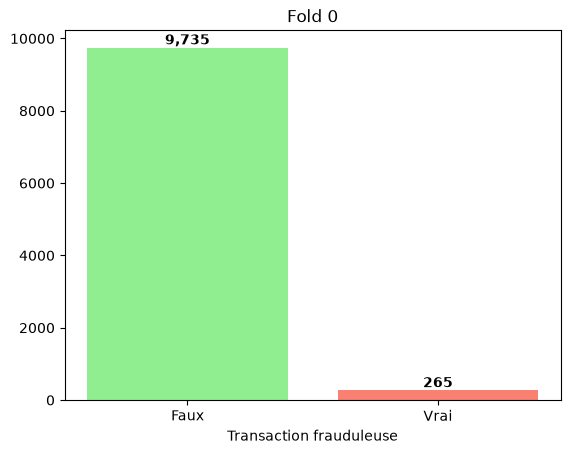

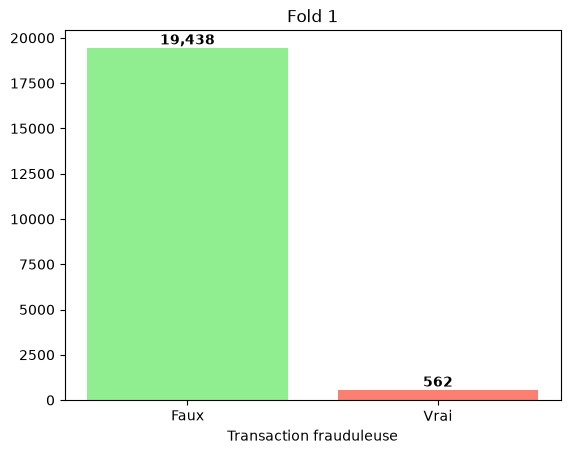

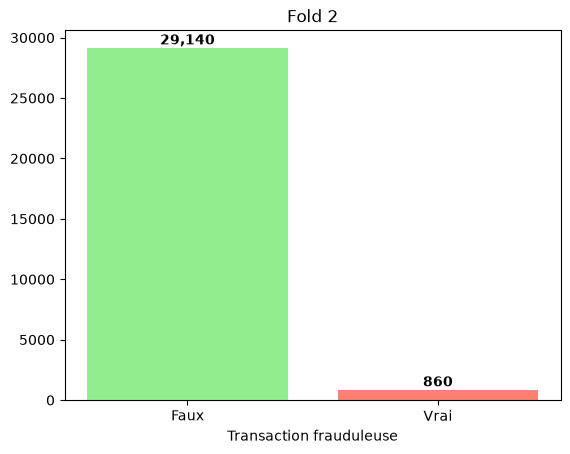

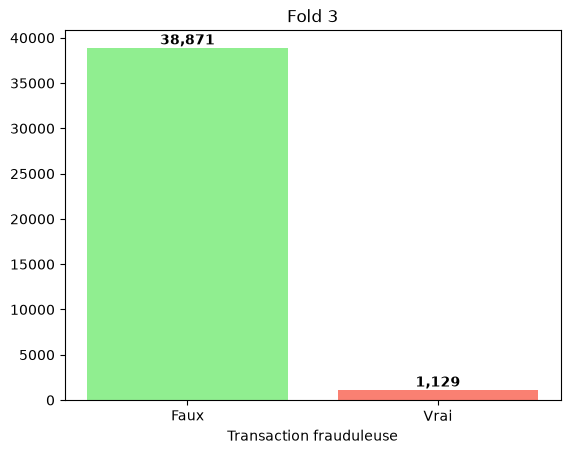

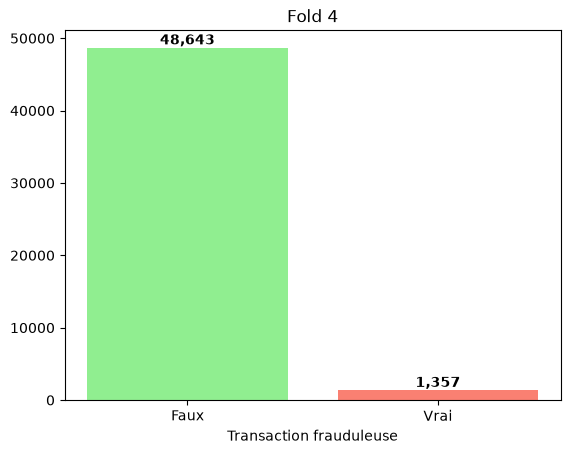

In [74]:
for fold, (train_idx, _) in enumerate(tscv.split(X)):
    y_train = y.iloc[train_idx]
    plot_classes(y_train,fold)

## Comparaison des stratégies avec XGBoost

### Fonction d'entrainement qui logue les expériences sur un serveur MLFlow (hébergé sur Dagshub).

In [41]:
mlflow.set_experiment("xgboost")
mlflow.enable_system_metrics_logging()
#mlflow.xgboost.autolog()
    
def train_and_log(strategy_name, pipeline, X, y):
    results = []
    with mlflow.start_run(run_name=strategy_name,log_system_metrics=True):
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            print(f"{fold=} ",end="")
        
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
            # entrainement
            training_time = time.time()
            pipeline.fit(X_train, y_train)
            training_time = time.time() - training_time
            print(f"{training_time:.2} s")
        
            # prédictions
            y_probs = pipeline.predict_proba(X_test)[:, 1]
            y_pred = (y_probs >= 0.5).astype(int)
        
            # calcul des métriques
            precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
            metrics = {
                #"aucpr": average_precision_score(y_test, y_probs),
                "aucpr":  auc(recall, precision),
                "recall_at_0.5": recall_score(y_test, y_pred),
                "f1_score": f1_score(y_test, y_pred),
                "training_time": training_time
            }

            results.append(metrics)

            #prefix = f"fold_{fold}_"
            #prefixed_metrics = {f"{prefix}{k}": v for k, v in metrics.items()}
            mlflow.log_metrics(metrics,step=fold)

            pipeline["clf"].set_params(device="cpu")
        
        metrics = pd.DataFrame(results).mean().to_dict()
        prefix = f"average_"
        prefixed_metrics = {f"{prefix}{k}": v for k, v in metrics.items()}

        mlflow.log_metrics(prefixed_metrics)
    print(f"stratégie {strategy_name} terminée.")
    return results    

### Définition des pipelines pour chaque stratégie

In [56]:
# 0. common
common_steps = [('imputer', SimpleImputer(strategy='median')),("scaler", StandardScaler())]

#### Baseline

In [56]:
base_steps = common_steps.copy()
base_steps.append(("clf",XGBClassifier(device="cuda",random_state=42)))
pipe_base = Pipeline(base_steps)

In [51]:
r = train_and_log("xgboost_baseline",pipe_base,X,y)

2026/06/25 17:59:41 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


fold=0 0.68 s
fold=1 6.4 s
fold=2 8.5 s
fold=3 1.5e+01 s
fold=4 1.1e+01 s


2026/06/25 18:00:26 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run xgboost_baseline at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2/runs/8211a4c13135433c8293d7c4ed6e8dc6
🧪 View experiment at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2


2026/06/25 18:00:26 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


stratégie xgboost_baseline terminée.


#### xgboost pondéré (scale_pos_weight)

In [56]:
ratio =(y_train==0).sum()/(y_train==1).sum()
weighted_steps = common_steps.copy()
weighted_steps.append(('clf', XGBClassifier(device="cuda",scale_pos_weight=ratio, random_state=42)))
pipe_weighted = Pipeline(weighted_steps)

In [59]:
r = train_and_log("xgboost_weighted",pipe_weighted,X,y)

2026/06/25 18:11:24 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


fold=0 0.76 s
fold=1 2.6e+01 s
fold=2 2e+01 s
fold=3 2.3e+01 s
fold=4 2.2e+01 s


2026/06/25 18:13:00 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run xgboost_weighted at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2/runs/ec0d3a53e7ca491ab759364064d4e0f4
🧪 View experiment at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2


2026/06/25 18:13:00 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


stratégie xgboost_weighted terminée.


#### randomundersampler

In [56]:
rus_steps = common_steps.copy()
rus_steps.append(('sampler', RandomUnderSampler(sampling_strategy="majority",random_state=42)))
rus_steps.append(('clf', XGBClassifier(device="cuda")))
pipe_rus = Pipeline(rus_steps)

In [52]:
r = train_and_log("xgboost_undersampling",pipe_rus,X,y)

2026/06/25 18:00:27 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


fold=0 0.72 s
fold=1 3.3 s
fold=2 1e+01 s
fold=3 7.2 s
fold=4 4.2 s


2026/06/25 18:00:55 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run xgboost_undersampling at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2/runs/285d819f8517436c91a6034ef7987403
🧪 View experiment at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2


2026/06/25 18:00:56 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


stratégie xgboost_undersampling terminée.


In [ ]:
#### smote

In [56]:
smote_steps = common_steps.copy()
smote_steps.append(('sampler', SMOTE(random_state=42)))
smote_steps.append(('clf', XGBClassifier(device="cuda", random_state=42)))
pipe_smote = Pipeline(smote_steps)

In [57]:
r = train_and_log("xgboost_smote",pipe_smote,X,y)

2026/06/25 18:01:49 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


fold=0 1.2 s
fold=1 2.6e+01 s
fold=2 2.2e+01 s
fold=3 1.8e+01 s
fold=4 2.6e+01 s
🏃 View run xgboost_smote at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2/runs/f732055d314b4502abda1a5c7723b017
🧪 View experiment at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2


2026/06/25 18:03:25 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/06/25 18:03:26 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


stratégie xgboost_smote terminée.


#### smote + enn

In [56]:
smoteenn_steps = common_steps.copy()
smoteenn_steps.append(('sampler', SMOTEENN(sampling_strategy='auto',random_state=42)))
smoteenn_steps.append(('clf', XGBClassifier(device="cuda", random_state=42)))
pipe_smote_enn = Pipeline(smoteenn_steps)

In [58]:
r = train_and_log("xgboost_smoteenn",pipe_smote_enn,X,y)

2026/06/25 18:03:41 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


fold=0 5.4 s
fold=1 2.8e+01 s
fold=2 4.2e+01 s
fold=3 7.7e+01 s
fold=4 1.1e+02 s


2026/06/25 18:08:03 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run xgboost_smoteenn at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2/runs/76c8e36d03e84ceea6fdd611501a2c91
🧪 View experiment at: https://dagshub.com/xavier.trentin/fraud-scope.mlflow/#/experiments/2


2026/06/25 18:08:03 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


stratégie xgboost_smoteenn terminée.
